In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/ache_ic50_clean.csv")

print(df.shape)
df.head()

(6288, 4)


,molecule_chembl_id,canonical_smiles,pIC50,n_measurements
0,CHEMBL100334,CN(CCOCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,6.920819,1
1,CHEMBL100366,CN1CC[C@@]2(C)c3cc(OC(=O)Nc4ccccc4)ccc3N(C=O)C12,6.107683,1
2,CHEMBL100510,CN(CCOCCNC(=S)NC(=O)c1ccc2ccccc2c1)Cc1ccccc1,7.000000,1
3,CHEMBL101028,CN(CCOCCNC(=S)Nc1ccc(OC(F)(F)F)cc1)Cc1ccccc1,6.000000,1
4,CHEMBL101155,CN(CCOCCCNC(=S)NC(=O)c1ccccc1)Cc1ccccc1,5.958607,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6288 non-null   str    
 1   canonical_smiles    6288 non-null   str    
 2   pIC50               6288 non-null   float64
 3   n_measurements      6288 non-null   int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 196.6 KB


In [3]:
df["pIC50"].describe()

/home/susmita/bin/anaconda3/envs/Hypothesis_Testing/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    6288.000000
mean             inf
std              NaN
min         0.786000
25%         4.978806
50%         5.860121
75%         6.939302
max              inf
Name: pIC50, dtype: float64

In [4]:
print("NaN:", df["pIC50"].isna().sum())
print("+inf:", np.isposinf(df["pIC50"]).sum())
print("-inf:", np.isneginf(df["pIC50"]).sum())

NaN: 0
+inf: 1
-inf: 0


In [5]:
df = df[np.isfinite(df["pIC50"])].copy()
df.to_csv("ache_ic50_clean.csv", index=False)

In [6]:
print("Dataset size:", df.shape)
print("Non-finite pIC50:", (~np.isfinite(df["pIC50"])).sum())

Dataset size: (6287, 4)
Non-finite pIC50: 0


In [7]:
df["pIC50"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    6287.000000
mean        5.981279
std         1.515109
min         0.786000
1%          2.807834
5%          3.719491
25%         4.978801
50%         5.860121
75%         6.937422
95%         8.492686
99%         9.698970
max        14.301030
Name: pIC50, dtype: float64

In [8]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

In [9]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

In [10]:
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    fp = morgan_gen.GetFingerprint(mol)

    arr = np.zeros((2048,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

In [11]:
#First Test 1 Molecule
test_smiles = df.iloc[0]["canonical_smiles"]

test_fp = smiles_to_fp(test_smiles)

print("Shape:", test_fp.shape)
print("Unique values:", np.unique(test_fp))
print("ON bits:", test_fp.sum())

Shape: (2048,)
Unique values: [0 1]
ON bits: 44


In [12]:
#Convert all 6287 ligands into fingerprints
X = np.array([
    smiles_to_fp(smiles)
    for smiles in df["canonical_smiles"]
])

y = df["pIC50"].to_numpy()

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X unique values:", np.unique(X))
print("y finite:", np.isfinite(y).all())

X shape: (6287, 2048)
y shape: (6287,)
X unique values: [0 1]
y finite: True


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5029, 2048)
X_test : (1258, 2048)
y_train: (5029,)
y_test : (1258,)


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Learn relationship between fingerprint and pIC50
rf.fit(X_train, y_train)

# Predict pIC50 for test molecules
y_pred = rf.predict(X_test)
X_train[1]
print("Predictions:", y_pred.shape)
print(y_pred[:10])

Predictions: (1258,)
[5.81269655 7.38040427 6.32715509 4.1594892  7.6001343  5.78478137
 3.33484987 5.70141521 4.08758581 6.0829161 ]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.533
RMSE : 0.765
R²   : 0.734


In [18]:
residuals = y_test - y_pred

print("Mean residual:", residuals.mean())
print("Largest positive residual:", residuals.max())
print("Largest negative residual:", residuals.min())

Mean residual: -0.006157053168948662
Largest positive residual: 3.958602021405701
Largest negative residual: -3.424584671073588


In [19]:
abs_error = np.abs(residuals)

print("Largest absolute error:", abs_error.max())

Largest absolute error: 3.958602021405701


In [20]:
#Which molecule failed
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

test_results = df.iloc[test_idx].copy()

test_results["experimental_pIC50"] = y_test
test_results["predicted_pIC50"] = y_pred
test_results["residual"] = y_test - y_pred
test_results["absolute_error"] = np.abs(test_results["residual"])
test_results.head()

,molecule_chembl_id,canonical_smiles,pIC50,n_measurements,experimental_pIC50,predicted_pIC50,residual,absolute_error
4442,CHEMBL4782180,Oc1ccccc1-c1nnc(N2CCN(c3ccccn3)CC2)o1,5.910095,1,5.910095,5.812697,0.097398,0.097398
3658,CHEMBL4278686,COc1nc(-c2ccnc(NC(=O)C3CC3)c2)sc1C(=O)NCCCNc1c...,8.193820,1,8.193820,7.380404,0.813416,0.813416
6068,CHEMBL6171343,COc1ccc2c3c1O[C@H]1C[C@@H](OC(=O)NC4CCN(Cc5ccc...,6.220815,1,6.220815,6.327155,-0.106340,0.106340
5320,CHEMBL5397966,CN(C)CCCN1C(=O)CSC1c1cccc(Cl)c1.Cl,4.602060,1,4.602060,4.159489,0.442571,0.442571
1539,CHEMBL243062,CCN(CCCCCCNC1=C(Br)C(=O)C(NCCCCCCN(CC)Cc2ccccc...,8.575118,1,8.575118,7.600134,0.974984,0.974984


In [21]:
worst = test_results.sort_values(
    "absolute_error",
    ascending=False
)

worst[
    [
        "molecule_chembl_id",
        "canonical_smiles",
        "experimental_pIC50",
        "predicted_pIC50",
        "residual",
        "absolute_error"
    ]
].head(10)

,molecule_chembl_id,canonical_smiles,experimental_pIC50,predicted_pIC50,residual,absolute_error
6047,CHEMBL6167736,Cc1ccc(O)c(CNc2c(N)n(C)c(=O)n(C)c2=O)c1,8.332547,4.373945,3.958602,3.958602
4183,CHEMBL4647106,COc1ccc([C@H](O)[C@H](N)C(=O)O)cc1OC,9.000000,5.106397,3.893603,3.893603
2063,CHEMBL3313966,O=C(C[n+]1ccccc1)N/N=C/c1ccc(/C=N/NC(=O)C[n+]2...,8.638272,4.929626,3.708646,3.708646
2389,CHEMBL345241,CC1CCN(CC2CCCCC2)CC1,8.050610,4.389519,3.661091,3.661091
4718,CHEMBL4859173,Cl.Nc1c2c(nc3cccc(Cl)c13)CCCCC2,3.651695,7.076280,-3.424585,3.424585
14,CHEMBL1025,CC(C)OP(=O)(F)OC(C)C,6.920819,3.499766,3.421053,3.421053
5229,CHEMBL5280980,C[n+]1ccc2c3ccccc3n(CCc3ccccc3)c2c1,9.301030,5.944920,3.356110,3.356110
1142,CHEMBL202661,O=C(CCCCCNc1c2c(nc3cccc(Cl)c13)CCCC2)NCCc1c[nH...,9.060481,12.163979,-3.103498,3.103498
1103,CHEMBL199585,O=C(CCCCCCNc1c2c(nc3cc(Cl)cc(Cl)c13)CCCC2)NCCc...,11.096910,14.105467,-3.008557,3.008557
318,CHEMBL1200970,CCN(CC)C(C)CN1c2ccccc2Sc2ccccc21.Cl,2.991400,5.918432,-2.927032,2.927032


In [22]:
train_fps = []

for idx in train_idx:
    mol = Chem.MolFromSmiles(df.iloc[idx]["canonical_smiles"])
    fp = morgan_gen.GetFingerprint(mol)
    train_fps.append(fp)

In [23]:
#Maximum training similarity for each test molecule:
max_similarities = []
nearest_train_indices = []

for idx in test_idx:
    mol = Chem.MolFromSmiles(df.iloc[idx]["canonical_smiles"])
    test_fp = morgan_gen.GetFingerprint(mol)

    similarities = DataStructs.BulkTanimotoSimilarity(
        test_fp,
        train_fps
    )

    best_position = np.argmax(similarities)

    max_similarities.append(similarities[best_position])
    nearest_train_indices.append(train_idx[best_position])

In [24]:
test_results["max_train_similarity"] = max_similarities
test_results["nearest_train_idx"] = nearest_train_indices
pd.Series(max_similarities).describe()

count    1258.000000
mean        0.794769
std         0.162902
min         0.191011
25%         0.725934
50%         0.812500
75%         0.916373
max         1.000000
dtype: float64

In [25]:
test_results.sort_values(
    "absolute_error",
    ascending=False
)[
    [
        "molecule_chembl_id",
        "experimental_pIC50",
        "predicted_pIC50",
        "absolute_error",
        "max_train_similarity"
    ]
].head(10)

,molecule_chembl_id,experimental_pIC50,predicted_pIC50,absolute_error,max_train_similarity
6047,CHEMBL6167736,8.332547,4.373945,3.958602,0.354167
4183,CHEMBL4647106,9.000000,5.106397,3.893603,0.441860
2063,CHEMBL3313966,8.638272,4.929626,3.708646,0.403509
2389,CHEMBL345241,8.050610,4.389519,3.661091,0.375000
4718,CHEMBL4859173,3.651695,7.076280,3.424585,0.970588
14,CHEMBL1025,6.920819,3.499766,3.421053,0.291667
5229,CHEMBL5280980,9.301030,5.944920,3.356110,0.585366
1142,CHEMBL202661,9.060481,12.163979,3.103498,1.000000
1103,CHEMBL199585,11.096910,14.105467,3.008557,1.000000
318,CHEMBL1200970,2.991400,5.918432,2.927032,0.968750


In [26]:
#Retrieve information about the nearest training molecule:
test_results["nearest_train_chembl"] = [
    df.iloc[idx]["molecule_chembl_id"]
    for idx in nearest_train_indices
]

test_results["nearest_train_pIC50"] = [
    df.iloc[idx]["pIC50"]
    for idx in nearest_train_indices
]

test_results["nearest_train_smiles"] = [
    df.iloc[idx]["canonical_smiles"]
    for idx in nearest_train_indices
]

In [27]:
test_results.sort_values(
    "absolute_error",
    ascending=False
)[
    [
        "molecule_chembl_id",
        "experimental_pIC50",
        "predicted_pIC50",
        "absolute_error",
        "max_train_similarity",
        "nearest_train_chembl",
        "nearest_train_pIC50"
    ]
].head(10)

,molecule_chembl_id,experimental_pIC50,predicted_pIC50,absolute_error,max_train_similarity,nearest_train_chembl,nearest_train_pIC50
6047,CHEMBL6167736,8.332547,4.373945,3.958602,0.354167,CHEMBL4292574,3.476904
4183,CHEMBL4647106,9.000000,5.106397,3.893603,0.441860,CHEMBL3585782,10.571056
2063,CHEMBL3313966,8.638272,4.929626,3.708646,0.403509,CHEMBL3597941,3.004365
2389,CHEMBL345241,8.050610,4.389519,3.661091,0.375000,CHEMBL6142005,6.779892
4718,CHEMBL4859173,3.651695,7.076280,3.424585,0.970588,CHEMBL4862288,7.476254
14,CHEMBL1025,6.920819,3.499766,3.421053,0.291667,CHEMBL494887,3.468521
5229,CHEMBL5280980,9.301030,5.944920,3.356110,0.585366,CHEMBL3605361,9.481486
1142,CHEMBL202661,9.060481,12.163979,3.103498,1.000000,CHEMBL4589980,11.096910
1103,CHEMBL199585,11.096910,14.105467,3.008557,1.000000,CHEMBL199538,14.301030
318,CHEMBL1200970,2.991400,5.918432,2.927032,0.968750,CHEMBL1206,6.522879


In [28]:
for test_id in ["CHEMBL202661", "CHEMBL199585", "CHEMBL4859173" ]:
    
    row = test_results[
        test_results["molecule_chembl_id"] == test_id
    ].iloc[0]

    print("\nTEST:", test_id)
    print("Test SMILES:")
    print(row["canonical_smiles"])
    
    print("\nNearest training molecule:")
    print(row["nearest_train_chembl"])
    print("Training SMILES:")
    print(row["nearest_train_smiles"])
    
    print("Tanimoto:", row["max_train_similarity"])
    print("Test pIC50:", row["experimental_pIC50"])
    print("Nearest training pIC50:", row["nearest_train_pIC50"])


TEST: CHEMBL202661
Test SMILES:
O=C(CCCCCNc1c2c(nc3cccc(Cl)c13)CCCC2)NCCc1c[nH]c2ccccc12

Nearest training molecule:
CHEMBL4589980
Training SMILES:
O=C(CCCCCCNc1c2c(nc3cccc(Cl)c13)CCCC2)NCCc1c[nH]c2ccccc12
Tanimoto: 1.0
Test pIC50: 9.060480747381382
Nearest training pIC50: 11.096910013008056

TEST: CHEMBL199585
Test SMILES:
O=C(CCCCCCNc1c2c(nc3cc(Cl)cc(Cl)c13)CCCC2)NCCc1c[nH]c2ccccc12

Nearest training molecule:
CHEMBL199538
Training SMILES:
O=C(CCCCCNc1c2c(nc3cc(Cl)cc(Cl)c13)CCCC2)NCCc1c[nH]c2ccccc12
Tanimoto: 1.0
Test pIC50: 11.096910013008056
Nearest training pIC50: 14.30102999566398

TEST: CHEMBL4859173
Test SMILES:
Cl.Nc1c2c(nc3cccc(Cl)c13)CCCCC2

Nearest training molecule:
CHEMBL4862288
Training SMILES:
Cl.Nc1c2c(nc3cccc(Cl)c13)CCCC2
Tanimoto: 0.9705882352941176
Test pIC50: 3.6516951369518393
Nearest training pIC50: 7.476253533188435


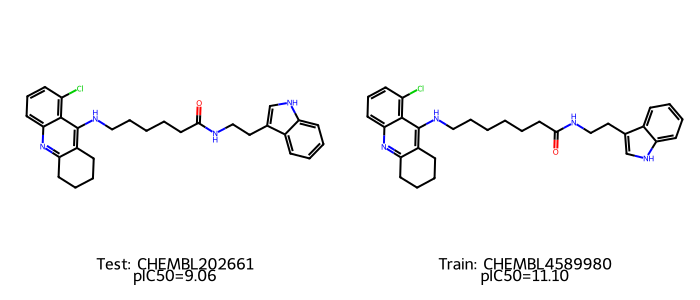

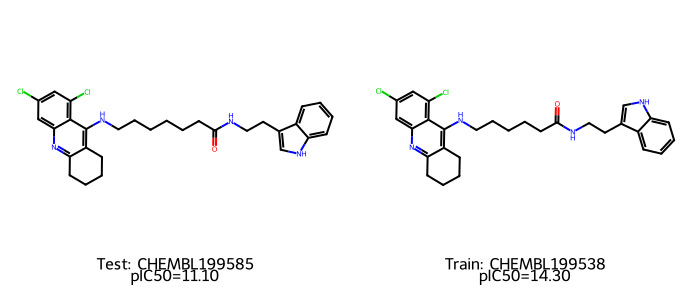

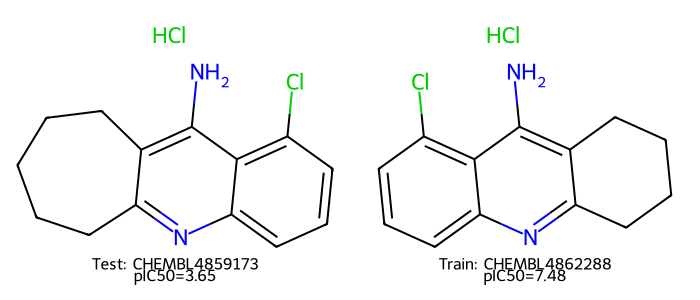

In [29]:
from rdkit.Chem import Draw
from IPython.display import display

for test_id in ["CHEMBL202661", "CHEMBL199585", "CHEMBL4859173"]:
    
    row = test_results[
        test_results["molecule_chembl_id"] == test_id
    ].iloc[0]

    test_mol = Chem.MolFromSmiles(row["canonical_smiles"])
    neighbor_mol = Chem.MolFromSmiles(row["nearest_train_smiles"])

    img = Draw.MolsToGridImage(
        [test_mol, neighbor_mol],
        legends=[
            f'Test: {row["molecule_chembl_id"]}\npIC50={row["experimental_pIC50"]:.2f}',
            f'Train: {row["nearest_train_chembl"]}\npIC50={row["nearest_train_pIC50"]:.2f}'
        ],
        molsPerRow=2,
        subImgSize=(350, 300)
    )

    display(img)

In [30]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# Select our interesting test molecule
row = test_results[
    test_results["molecule_chembl_id"] == "CHEMBL202661"
].iloc[0]

# Convert test and nearest-neighbor SMILES to molecules
test_mol = Chem.MolFromSmiles(
    row["canonical_smiles"]
)

neighbor_mol = Chem.MolFromSmiles(
    row["nearest_train_smiles"]
)

# Morgan generator
count_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Generate COUNT fingerprints
test_count_fp = count_gen.GetCountFingerprint(test_mol)
neighbor_count_fp = count_gen.GetCountFingerprint(neighbor_mol)

# Count-based Tanimoto similarity
count_similarity = DataStructs.TanimotoSimilarity(
    test_count_fp,
    neighbor_count_fp
)

print("Binary Morgan similarity:", row["max_train_similarity"])
print("Count Morgan similarity :", count_similarity)

Binary Morgan similarity: 1.0
Count Morgan similarity : 0.9716981132075472


In [31]:
test_counts = test_count_fp.GetNonzeroElements()
neighbor_counts = neighbor_count_fp.GetNonzeroElements()

different_bits = []

all_bits = set(test_counts) | set(neighbor_counts)

for bit in all_bits:
    test_value = test_counts.get(bit, 0)
    neighbor_value = neighbor_counts.get(bit, 0)

    if test_value != neighbor_value:
        different_bits.append(
            (bit, test_value, neighbor_value)
        )

print("Number of differing count features:", len(different_bits))
print("\n(bit, test count, train count)")

for item in different_bits:
    print(item)

Number of differing count features: 3

(bit, test count, train count)
(80, 7, 8)
(1143, 1, 2)
(1911, 3, 4)


In [32]:
count_similarity = DataStructs.TanimotoSimilarity(
    test_count_fp,
    neighbor_count_fp
)

print("Binary similarity:", row["max_train_similarity"])
print("Count similarity :", count_similarity)

Binary similarity: 1.0
Count similarity : 0.9716981132075472


In [33]:
correlation = test_results[
    ["absolute_error", "max_train_similarity"]
].corr()

correlation

,absolute_error,max_train_similarity
absolute_error,1.000000,-0.184452
max_train_similarity,-0.184452,1.000000


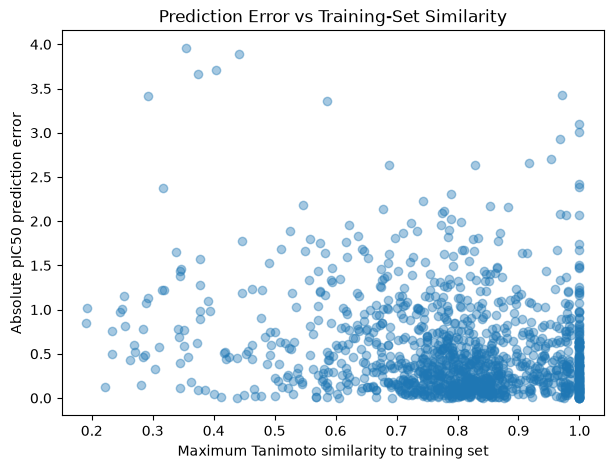

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    test_results["max_train_similarity"],
    test_results["absolute_error"],
    alpha=0.4
)

plt.xlabel("Maximum Tanimoto similarity to training set")
plt.ylabel("Absolute pIC50 prediction error")
plt.title("Prediction Error vs Training-Set Similarity")

plt.show()

In [35]:
df.to_csv("ache_ic50_clean.csv", index=False)